# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [ ]:
# Import necessary libraries for data manipulation, model building, and evaluation
%matplotlib inline
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import math
import scipy.stats as stats

## Load and Prepare Data

In this section, we load the NIFTY 50 data and preprocess it for modeling.


In [3]:
data_csv = pd.read_csv(r"NIFTY 50.csv")

data = data_csv[data_csv.columns[0:5]]
data = data[:5348]

# Convert 'Date' column to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'Date' column as the index
data.set_index('Date', inplace=True)

# Resample the data to monthly frequency
obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})

# Reset the index to have 'Date' as a column again
obs = obs.reset_index()

# Print the monthly data
print(obs)

data = obs[:162]
print(data)

          Date      Open      High       Low     Close
0   2000-01-31   1482.15   1671.15   1482.15   1546.20
1   2000-02-29   1546.20   1818.15   1521.40   1654.80
2   2000-03-31   1661.50   1773.85   1489.10   1528.45
3   2000-04-30   1528.70   1636.95   1311.30   1406.55
4   2000-05-31   1410.00   1436.60   1201.50   1380.45
..         ...       ...       ...       ...       ...
253 2021-02-28  13758.60  15431.75  13661.75  14529.15
254 2021-03-31  14702.50  15336.30  14264.40  14690.70
255 2021-04-30  14798.40  15044.35  14151.40  14631.10
256 2021-05-31  14481.05  15606.35  14416.25  15582.80
257 2021-06-30  15629.65  15915.65  15450.90  15721.50

[258 rows x 5 columns]
          Date     Open     High      Low    Close
0   2000-01-31  1482.15  1671.15  1482.15  1546.20
1   2000-02-29  1546.20  1818.15  1521.40  1654.80
2   2000-03-31  1661.50  1773.85  1489.10  1528.45
3   2000-04-30  1528.70  1636.95  1311.30  1406.55
4   2000-05-31  1410.00  1436.60  1201.50  1380.45
..        

C:\Users\asker\AppData\Local\Temp\ipykernel_9368\942169131.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

T=  162


c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


HMM Prices: 
[np.float64(5742.0), np.float64(5471.8), np.float64(5208.3), np.float64(5171.450000000001), np.float64(6862.999999999999), np.float64(6304.0), np.float64(6089.5), np.float64(5875.0), np.float64(6062.45), np.float64(6696.4), np.float64(7123.65), np.float64(7417.4), np.float64(7992.750000000001), np.float64(7713.5), np.float64(8487.900000000001), np.float64(8322.2), np.float64(8588.25), np.float64(8282.7), np.float64(7977.1500000000015), np.float64(9074.949999999999), np.float64(9167.9), np.float64(9017.199999999999), np.float64(8274.45), np.float64(8368.5), np.float64(8532.85), np.float64(8467.7), np.float64(7409.75), np.float64(8065.8), np.float64(7935.25), np.float64(7946.35), np.float64(8063.250000000001), np.float64(6987.05), np.float64(6425.5), np.float64(7161.9), np.float64(8160.1), np.float64(8253.050000000001), np.float64(8222.6), np.float64(8802.85), np.float64(8480.650000000001), np.float64(8739.05), np.float64(8411.2), np.float64(8010.0), np.float64(7971.3), np.f

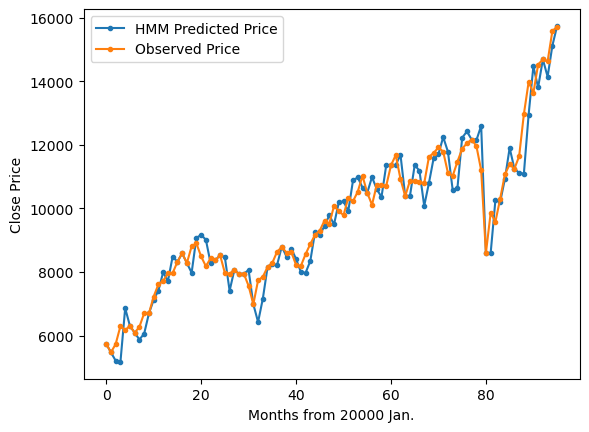

In [9]:
data = data[data.columns[1:5]]
obs = obs[obs.columns[1:5]]
# Calculate number of rows and set training window
T = data.shape[0]
print("T= ", T)

# Define the size of the training window
d = 96
D = 96
hmm_price = []

temp_T = T
first_time = True

# Sliding window approach to predict future prices
while T < temp_T + d:

    # Train HMM on data from T-D+1 to T
    train_data = obs.iloc[T-D:T]
    train_data = train_data.dropna()

    # Set the random seed
    np.random.seed(123)

    if(first_time):
      first_time = False
      model = hmm.GaussianHMM(n_components=5)
    else:
      old_model= model
      model = hmm.GaussianHMM(n_components=5, init_params="c")
      model.startprob_ = old_model.startprob_
      model.transmat_ = old_model.transmat_
      model.means_ = old_model.means_

    model.fit(train_data)

    # Calculate original likelihood
    original_likelihood = model.score(train_data)

    # Loop to find new likelihood
    t=T
    min_diff = float('inf')
    min_t = T
    min_likelihood = original_likelihood
    while t-D>  0:
        t = t-1

        train_data = obs.iloc[t-D:t]
        new_likelihood = model.score(train_data)
        if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
            min_diff = abs(new_likelihood - original_likelihood)
            min_t = t
            min_likelihood = new_likelihood

    # Calculate the predicted close price
    close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))

    hmm_price.append(close_price)
    T=T+1

# Print the calculated prices
print("HMM Prices: ")
print(hmm_price)

# Plot the predicted and observed prices
close = []
truncated_obs = obs.iloc[T-d:T]

for i in truncated_obs['Close']:
  close.append(i)

plt.plot(hmm_price,marker='.', label = "HMM Predicted Price")
plt.plot(close,marker = '.', label= "Observed Price")
plt.ylabel("Close Price")
plt.xlabel('Months from 20000 Jan.')
plt.legend()
plt.show()

## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


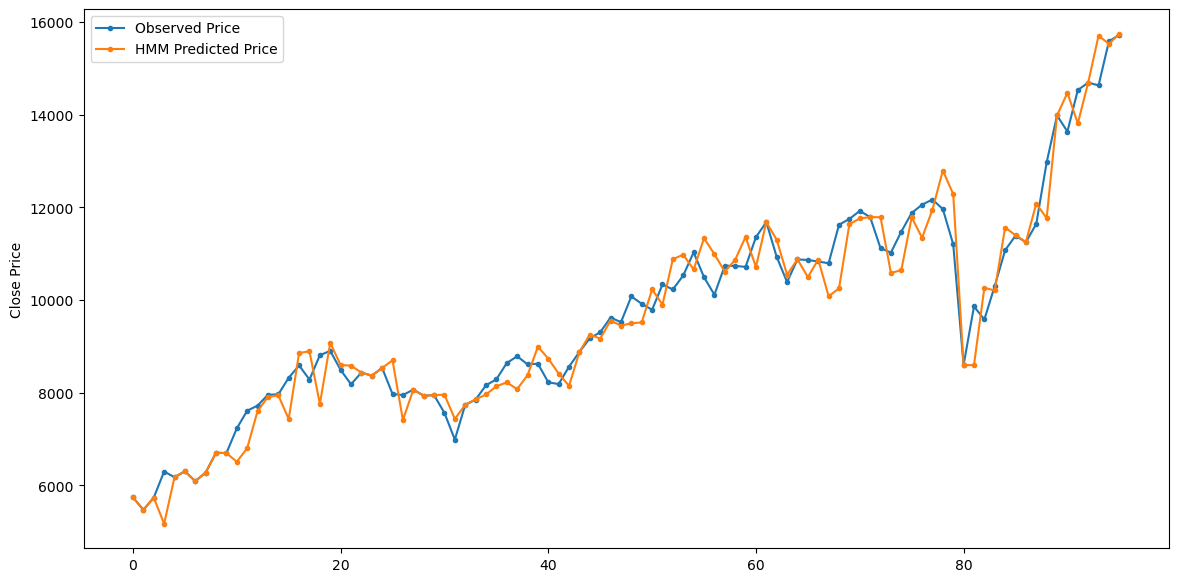

In [5]:
plt.figure(figsize=(14, 7))

# Plot actual prices for the corresponding period
plt.plot(close, marker='.', label='Observed Price')

# Plot HMM predicted prices
plt.plot(hmm_price, marker='.', label='HMM Predicted Price')

plt.ylabel("Close Price")
plt.legend()
plt.show()


-1084.3500000000004 1375.25


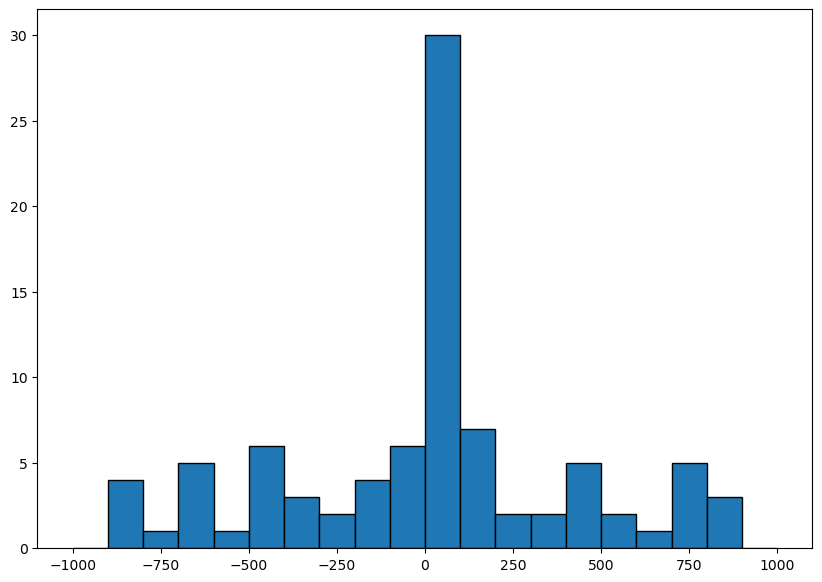

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
close = np.array(close)

hmm_price = np.array(hmm_price)
resids = close - hmm_price
print(np.min(resids), np.max(resids))
xmin = -1000
xmax = 1000
# ax.plot(resids, '.', label='Residuals (Observed - HMM Predicted)')
ax.hist(resids, bins=20, range=(xmin, xmax), edgecolor='black');

## Model Comparison and Efficiency Calculation

In this section, we calculate various error metrics for each model and determine the efficiency of HMM compared to LSTM, ARIMA, and RNN.


In [7]:
# Convert lists to numpy arrays
close = np.array(close)
hmm_price = np.array(hmm_price)

# Ensure all are trimmed to the same length
min_length = min(len(close), len(hmm_price))
print(min_length)
close = close[-min_length:]
hmm_price = hmm_price[-min_length:]

# 1. Absolute Percentage Error (APE)
def ape(real_, pred_):
    APE = 0
    sum = 0
    N = len(real_)
    # Calculate the sum of absolute differences between real and predicted values
    for i in range(1, N):
        sum += (np.abs(real_[i] - pred_[i])) / N

    # Calculate APE as a ratio of the sum to the mean of real values
    APE = sum / (np.mean(real_))

    return APE

ape_hmm = ape(close, hmm_price)

# 2. Average Absolute Error (AAE)
def aae(real_, pred_):
  AAE = 0
  sum = 0
  N = len(real_)
  for i in range(1,N):
    sum += (np.abs(real_[i] - pred_[i]))/N
  AAE = sum
  return AAE

aae_hmm = aae(close, hmm_price)

# 3. Average Relative Percentage Error (ARPE)
def arpe(real_, pred_):

  sum = 0
  N = len(real_)
  for i in range(1,N):
    sum += (np.abs(real_[i] - pred_[i]))/N
  ARPE = sum/N
  return ARPE

arpe_hmm = arpe(close, hmm_price)


# 4. Root Mean Squared Error (RMSE)
def rmse(real_, pred_):
  sum = 0
  N = len(real_)
  for i in range(1,N):
    sum += (np.square(real_[i] - pred_[i]))/N
  RMSE = np.sqrt(sum)
  return RMSE

rmse_hmm = rmse(close, hmm_price)


# 6. Efficiency Calculation
def efficiency(hmm_metric, other_metric):
    return 1 - (hmm_metric / other_metric)


96
